What Do People Ask Video AI to Generate? EDA of VidProM Dataset

In [3]:
from pydoc import describe

import pandas as pd
from wcwidth import width

In [4]:
df = pd.read_csv("../data/VidProm_unique.csv")
print(df.shape)
df.head()

(1672243, 9)


,uuid,prompt,time,toxicity,obscene,identity_attack,insult,threat,sexual_explicit
0,6a83eb92-faa0-572b-9e1f-67dec99b711d,"Flying among clouds and stars, kitten Max disc...",Sun Sep 3 12:27:44 2023,0.00129,0.00016,0.00007,0.00064,0.00002,0.00002
1,3ba1adf3-5254-59fb-a13e-57e6aa161626,Use a clean and modern font for the text &quot...,Wed Sep 13 18:15:30 2023,0.00038,0.00013,0.00008,0.00018,0.00003,0.00003
2,f88d8fff-1c26-59d2-8252-23ee67762b12,dancing sticks .screen size must be 9:16,Thu Sep 21 18:00:43 2023,0.01793,0.00536,0.00105,0.00199,0.00048,0.00118
3,871c822c-2a73-5fa6-b4ff-67f821813be1,promt robots hugging,Fri Aug 18 04:47:26 2023,0.02472,0.00682,0.00056,0.00850,0.00182,0.00092
4,3cbb0e22-a3b4-5841-a5a1-12db24ae656a,"ridley scott space documentary, 2020",Sat Sep 2 22:50:12 2023,0.00046,0.01469,0.00226,0.01080,0.00080,0.00050


### Data preparation

In [5]:
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 1672243 entries, 0 to 1672242
Data columns (total 9 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   uuid             1672243 non-null  str    
 1   prompt           1672243 non-null  str    
 2   time             1672243 non-null  str    
 3   toxicity         1672243 non-null  float64
 4   obscene          1672243 non-null  float64
 5   identity_attack  1672243 non-null  float64
 6   insult           1672243 non-null  float64
 7   threat           1672243 non-null  float64
 8   sexual_explicit  1672243 non-null  float64
dtypes: float64(6), str(3)
memory usage: 400.2 MB


In [6]:
print("gaps:")
print(df.isnull().sum())
print(f"\nduplicates: {df.duplicated().sum()}")

gaps:
uuid               0
prompt             0
time               0
toxicity           0
obscene            0
identity_attack    0
insult             0
threat             0
sexual_explicit    0
dtype: int64

duplicates: 0


In [8]:
df['prompt_length'] = df['prompt'].str.len()
df['word_count'] = df['prompt'].str.split().str.len()

print(df[['prompt_length', 'word_count']].describe())

       prompt_length    word_count
count   1.672243e+06  1.672243e+06
mean    1.186169e+02  1.846604e+01
std     1.692216e+02  2.339188e+01
min     1.000000e+00  0.000000e+00
25%     3.900000e+01  6.000000e+00
50%     6.800000e+01  1.100000e+01
75%     1.300000e+02  2.100000e+01
max     2.923300e+04  1.225000e+03


The shortest prompts

In [9]:
print(df.nsmallest(5, 'prompt_length')[['prompt', 'prompt_length']])

        prompt  prompt_length
248392       $              1
637628      +1              2
1156824     3D              2
1561845                     2
25963      ф                3


The longest prompts


In [10]:
print(df.nlargest(5, 'prompt_length')[['prompt', 'prompt_length']])

                                                    prompt  prompt_length
1117809  Space Philic Private Limited is a new-gen spac...          29233
639165   cataclysm approaches, a woman dances, cars are...          22642
167969   A very strong storm was coming in the forest a...          22580
196956   a girl in gym doing exercises, cataclysm appro...          22542
1222493  <img\n    loading="lazy"\n    class="chatlog__...          19575


In [17]:
df['time'] = pd.to_datetime(df['time'], format='%a %b %d %H:%M:%S %Y')
print(f"from: {df['time'].min()}")
print(f"to: {df['time'].max()}")
print(f"period: {df['time'].max() - df['time'].min()}")

from: 2023-06-29 08:20:41
to: 2024-03-03 18:03:41
period: 248 days 09:43:00


In [18]:
nsfw_cols = ['toxicity', 'obscene', 'identity_attack', 'insult', 'threat', 'sexual_explicit']
print(df[nsfw_cols].describe())

           toxicity       obscene  identity_attack        insult  \
count  1.672243e+06  1.672243e+06     1.672243e+06  1.672243e+06   
mean   3.662960e-02  4.616705e-03     5.104764e-03  1.486301e-02   
std    1.150096e-01  2.292117e-02     3.462123e-02  6.530927e-02   
min    8.000000e-05  5.000000e-05     4.000000e-05  9.000000e-05   
25%    6.700000e-04  3.800000e-04     1.800000e-04  5.200000e-04   
50%    2.260000e-03  9.200000e-04     4.300000e-04  1.610000e-03   
75%    1.303000e-02  2.760000e-03     1.450000e-03  5.910000e-03   
max    9.984600e-01  9.916300e-01     9.796500e-01  9.929800e-01   

             threat  sexual_explicit  
count  1.672243e+06     1.672243e+06  
mean   3.821824e-03     3.056091e-03  
std    3.103438e-02     3.424531e-02  
min    1.000000e-05     1.000000e-05  
25%    8.000000e-05     5.000000e-05  
50%    2.100000e-04     1.600000e-04  
75%    6.900000e-04     5.300000e-04  
max    9.657500e-01     9.912300e-01  


### Phase 1 Summary

Dataset: 1,672,243 unique prompts, 9 columns, zero nulls, zero duplicates

Prompts: median length 68 chars / 11 words. Range from 1 char to 29K chars

Outliers: shortest prompts are meaningless ("$", "+1"), longest are copy-paste junk and HTML

Time range: ~248 days (Aug 2023 - Apr 2024)

NSFW scores: all 0-1, medians near zero. Most prompts are clean, but a toxic tail exists

# Visualisation

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

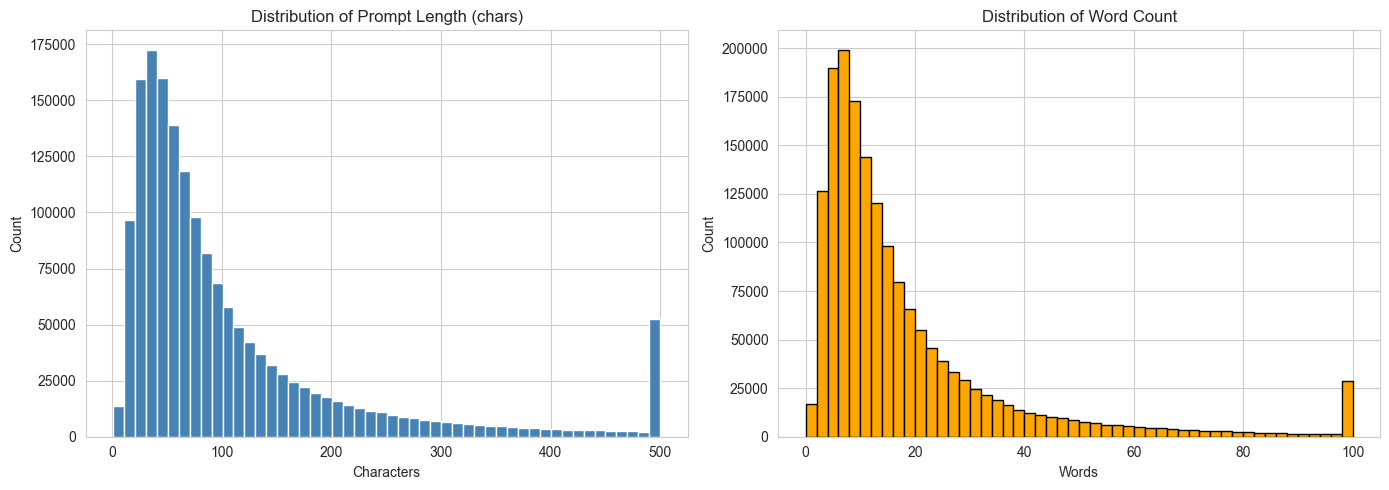

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hist prompt_length (trim it to 500 so that outliers don't flatten the graph)
axes[0].hist(df['prompt_length'].clip(upper=500), bins=50, color='steelblue')
axes[0].set_title('Distribution of Prompt Length (chars)')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Count')

# Hist word_count (trim it to 100)
axes[1].hist(df['word_count'].clip(upper=100), bins=50, edgecolor='black', color='orange')
axes[1].set_title('Distribution of Word Count')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../data/prompt_length_dist.png', dpi=150)
plt.show()

### Temporal Patterns

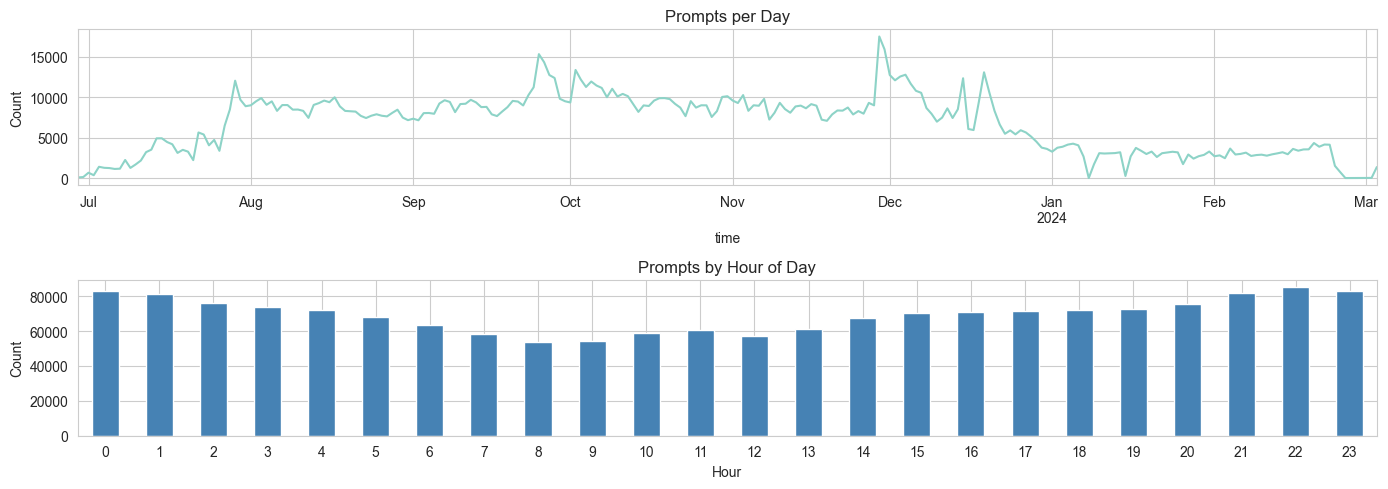

In [32]:
# Amount of prompts per day
daily = df.set_index('time').resample('D').size()

fig, axes = plt.subplots(2, 1, figsize=(14, 5))

# line plot - prompts per day
daily.plot(ax=axes[0])
axes[0].set_title('Prompts per Day')
axes[0].set_ylabel('Count')

# bar chart (distribution by hours of the day)
df['hour'] = df['time'].dt.hour
df['hour'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Prompts by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../data/temporal_patterns.png', dpi=150)
plt.show()

### NSFW Analysis

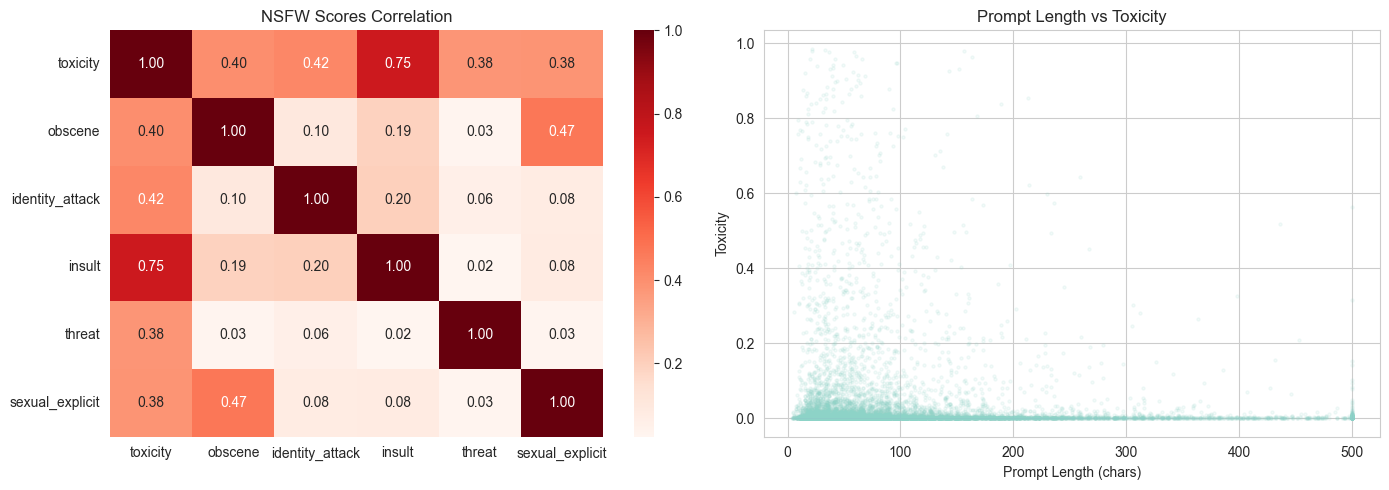

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap between 6 NSFW-scores
sns.heatmap(df[nsfw_cols].corr(), annot=True, fmt='.2f', cmap='Reds', ax=axes[0])
axes[0].set_title('NSFW Scores Correlation')
axes[0].tick_params(axis='x', rotation=0)

# Scatter: length of prompts vs toxicity
sample = df.sample(10000, random_state=42)
axes[1].scatter(sample['prompt_length'].clip(upper=500), sample['toxicity'], alpha=0.1, s=5)
axes[1].set_title('Prompt Length vs Toxicity')
axes[1].set_xlabel("Prompt Length (chars)")
axes[1].set_ylabel("Toxicity")

plt.tight_layout()
plt.savefig('../data/nsfw_analysis.png', dpi=150)
plt.show()

In [36]:
threshold = 0.5
for col in nsfw_cols:
    pct = (df[col] > threshold).mean() * 100
    print(f"{col}: {pct:.2f}% > {threshold}")

toxicity: 1.89% > 0.5
obscene: 0.06% > 0.5
identity_attack: 0.14% > 0.5
insult: 0.57% > 0.5
threat: 0.11% > 0.5
sexual_explicit: 0.16% > 0.5


### Text Frequency Analysis

In [38]:
from collections import Counter
from wordcloud import WordCloud

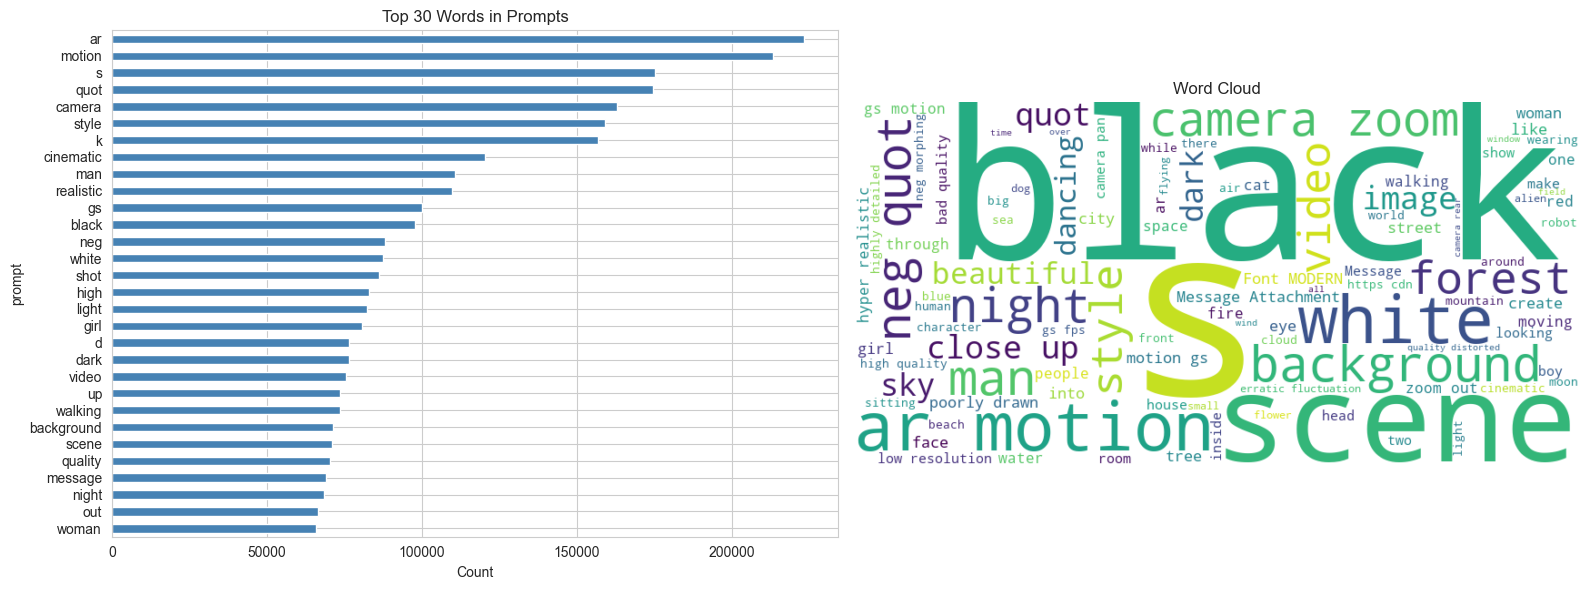

In [40]:
# stop-words — we remove function words that don't carry any meaning
stop_words = {'a', 'an', 'the', 'of', 'in', 'on', 'at', 'to', 'and', 'is', 'it',
                'for', 'with', 'that', 'this', 'are', 'was', 'be', 'as', 'by', 'or',
                'from', 'but', 'not', 'its', 'has', 'have', 'had', 'been', 'will',
                'can', 'do', 'does', 'did', 'he', 'she', 'they', 'we', 'you', 'i',
                'my', 'his', 'her', 'their', 'our', 'your', 'no', 'so', 'if', 'about'}

# count all the words
all_words = df['prompt'].str.lower().str.findall(r'[a-z]+').explode()
filtered = all_words[~all_words.isin(stop_words)]
top30 = filtered.value_counts().head(30)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# top-30 words
top30.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 30 Words in Prompts')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# WordCloud
wc = WordCloud(width=800, height=400, background_color='white',
               stopwords=stop_words, max_words=100)
wc.generate(' '.join(df['prompt'].dropna().sample(100000, random_state=42)))
axes[1].imshow(wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud')

plt.tight_layout()
plt.savefig('../data/text_frequency.png', dpi=150)
plt.show()

### Top 20 Bigrams (Pairs of Words)

In [41]:
from collections import Counter

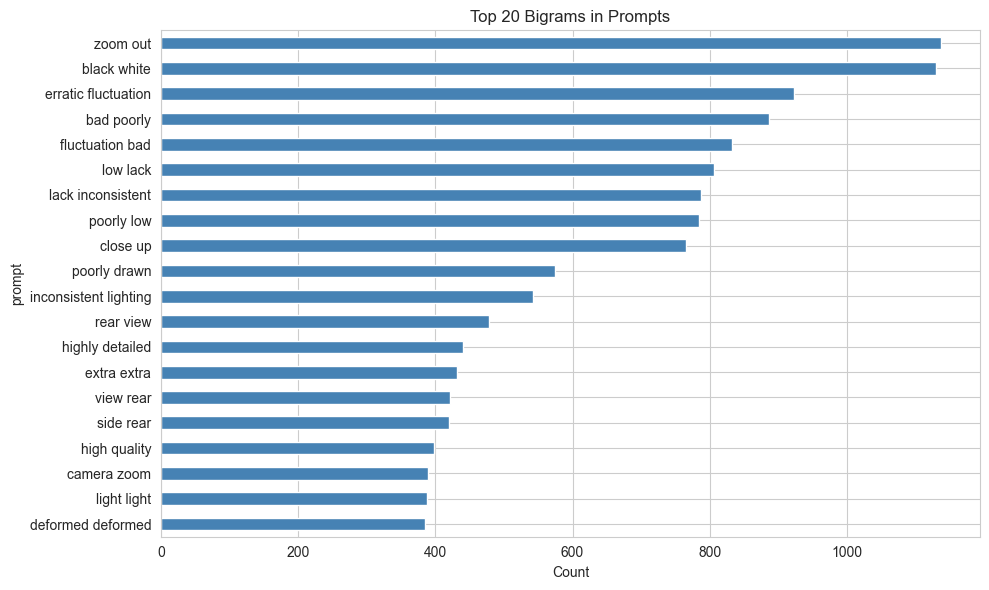

In [43]:
# Bigramms - pairs of adjacent words
def get_bigrams(text):
    words = [w for w in text.lower().split() if w.isalpha() and w not in stop_words]
    return list(zip(words, words[1:]))

bigrams = df['prompt'].sample(100000, random_state=42).apply(get_bigrams).explode()
top20_bigrams = bigrams.value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20_bigrams.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Top 20 Bigrams in Prompts')
ax.set_xlabel('Count')
ax.invert_yaxis()
# format signatures from tuples to strings
ax.set_yticklabels([f'{a} {b}' for a, b in top20_bigrams.index])

plt.tight_layout()
plt.savefig('../data/bigrams.png', dpi=150)
plt.show()

  ### Phase 2 Summary

Prompt length: right-skewed, median 68 chars / 11 words. Most prompts are concise descriptions

NSFW: 98% of prompts are clean. Toxicity is the most common flag (1.89% > 0.5)

Top themes: ar, motion, s, quote, camera

Top bigrams: zoom out, black white, erratic fluctuation, bad poorly, fluctuation bad (some bigrams suggest repetitive/spam prompts in the dataset)